<a href="https://colab.research.google.com/github/Hasinireddy-Ainavole/sklearn/blob/main/sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Q7: Build a Decision Tree (sklearn)

import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train decision trees with different max_depth values
depths = [1, 2, 3]
results = []

for depth in depths:
    # Create and train the decision tree
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    # Make predictions
    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)

    # Calculate accuracies
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append((depth, train_acc, test_acc))
    print(f"Max Depth {depth}: Train Accuracy = {train_acc:.4f}, Test Accuracy = {test_acc:.4f}")

# Analysis of underfitting vs overfitting
print("\nAnalysis:")
print("Depth 1: Likely underfitting - simple model, both accuracies relatively low")
print("Depth 2-3: Better balance - good performance without excessive complexity")
print("Generally, if train accuracy >> test accuracy, it indicates overfitting")
print("If both accuracies are low, it suggests underfitting")

Max Depth 1: Train Accuracy = 0.6476, Test Accuracy = 0.7111
Max Depth 2: Train Accuracy = 0.9429, Test Accuracy = 0.9778
Max Depth 3: Train Accuracy = 0.9524, Test Accuracy = 1.0000

Analysis:
Depth 1: Likely underfitting - simple model, both accuracies relatively low
Depth 2-3: Better balance - good performance without excessive complexity
Generally, if train accuracy >> test accuracy, it indicates overfitting
If both accuracies are low, it suggests underfitting


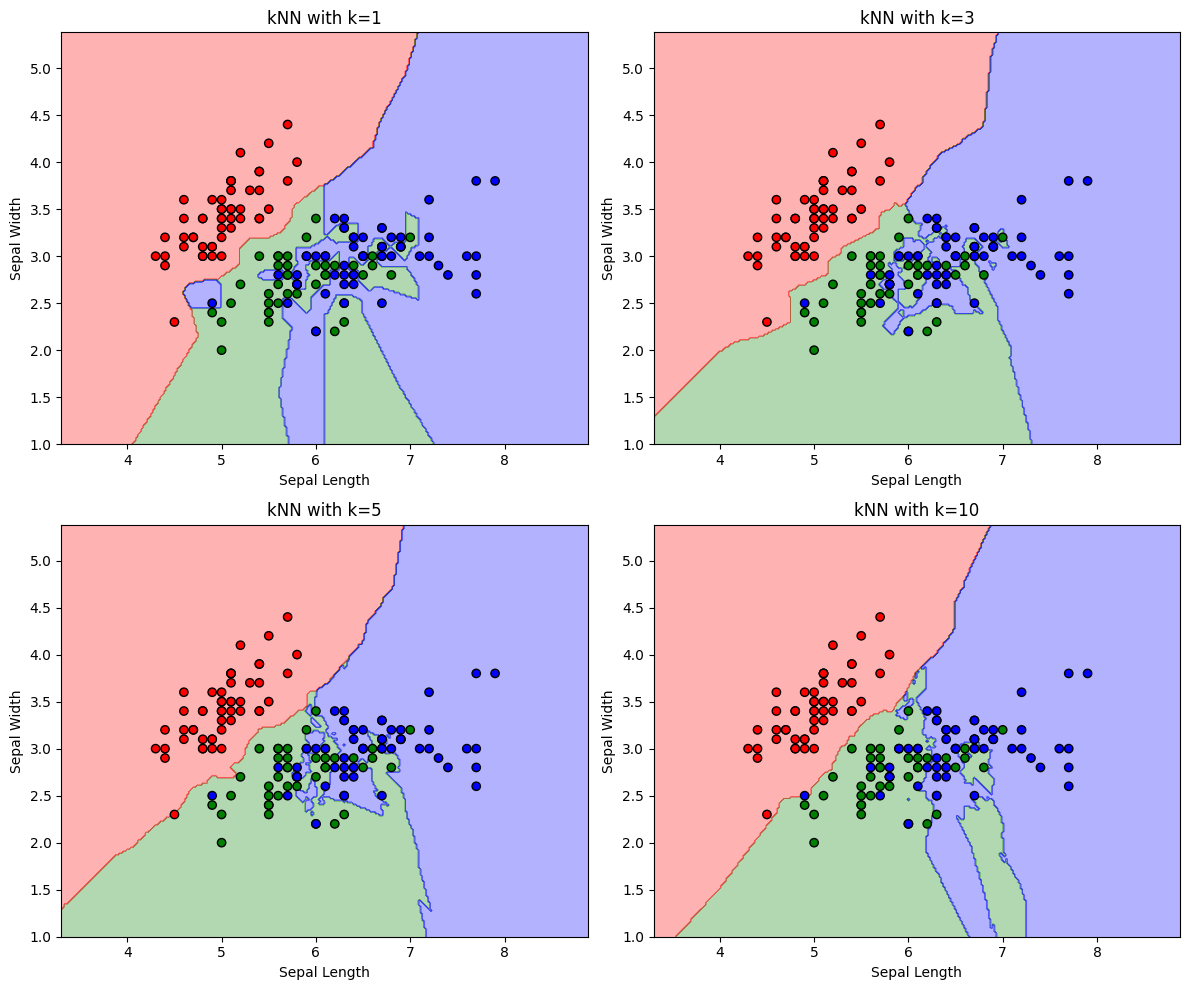

Decision Boundary Analysis:
k=1: Very complex, jagged boundaries - prone to overfitting
k=3: Smoother boundaries while capturing class structure
k=5: Even smoother, more generalized boundaries
k=10: Very smooth boundaries - may be too simple (underfitting)
As k increases, boundaries become smoother and more generalized


In [2]:
# Q8: kNN Classification (sklearn)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

# Load Iris dataset and use only 2 features (sepal length, sepal width)
iris = load_iris()
X = iris.data[:, :2]  # Only sepal length and sepal width
y = iris.target

# Define k values to test
k_values = [1, 3, 5, 10]

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Color map for visualization
colors = ['red', 'green', 'blue']
cmap = ListedColormap(colors[:len(np.unique(y))])

for i, k in enumerate(k_values):
    # Train kNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)

    # Create a mesh for decision boundary
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict on mesh points
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

    # Plot data points
    scatter = axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolors='black')
    axes[i].set_title(f'kNN with k={k}')
    axes[i].set_xlabel('Sepal Length')
    axes[i].set_ylabel('Sepal Width')

plt.tight_layout()
plt.show()

# Comments on boundary changes
print("Decision Boundary Analysis:")
print("k=1: Very complex, jagged boundaries - prone to overfitting")
print("k=3: Smoother boundaries while capturing class structure")
print("k=5: Even smoother, more generalized boundaries")
print("k=10: Very smooth boundaries - may be too simple (underfitting)")
print("As k increases, boundaries become smoother and more generalized")

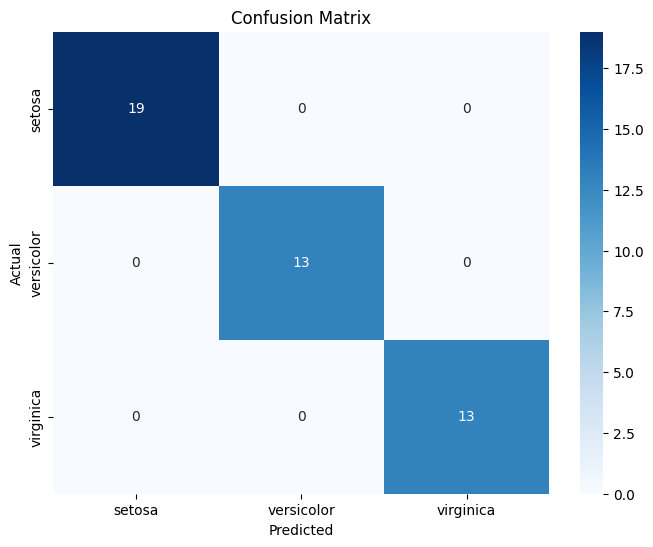

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



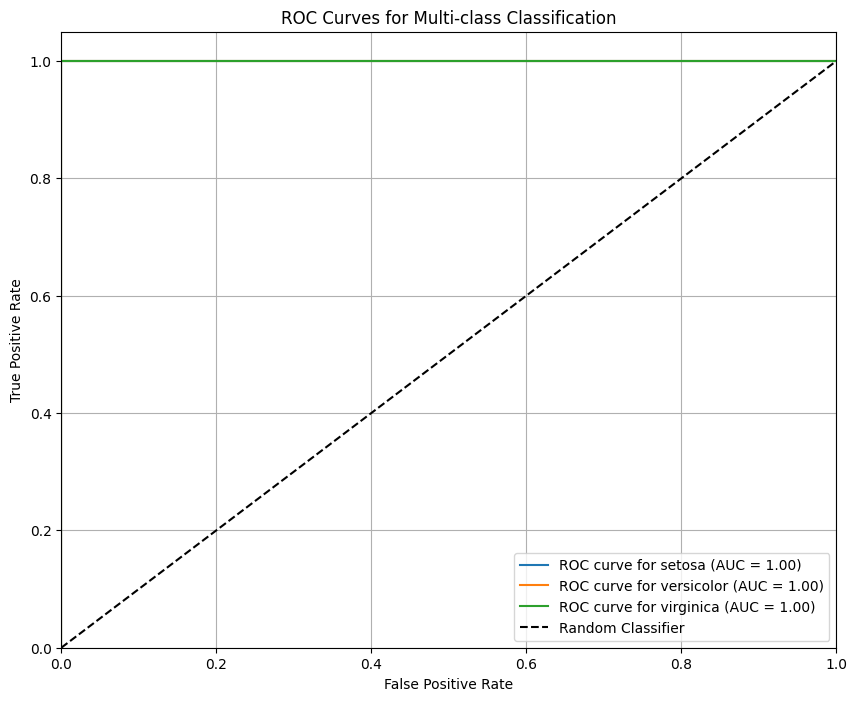


AUC Values:
setosa: 1.0000
versicolor: 1.0000
virginica: 1.0000
Macro-average AUC: 1.0000


In [3]:
# Q9: Performance Evaluation Programming

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns

# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train kNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# 1. Compute and display confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix:")
print(cm)

# 2. Compute accuracy, precision, recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 3. Plot ROC curve and compute AUC for multiclass
# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = knn.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 3

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i],
             label=f'ROC curve for {iris.target_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-class Classification')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Print AUC values
print("\nAUC Values:")
for i in range(n_classes):
    print(f"{iris.target_names[i]}: {roc_auc[i]:.4f}")

# Compute macro-average AUC
macro_auc = np.mean(list(roc_auc.values()))
print(f"Macro-average AUC: {macro_auc:.4f}")